# 03 — Data Mining: Apriori + K-Means Clustering
  **Đề tài 9: Phân tích chất lượng nước**

  ## Mục tiêu
  1. **Rời rạc hoá** chỉ số → Low/Medium/High → tạo transactions
  2. **Apriori / FP-Growth** tìm frequent itemsets → sinh luật kết hợp
  3. Đánh giá luật: **Support, Confidence, Lift, Coverage**
  4. Diễn giải top luật theo ngưỡng WHO
  5. **Elbow + Silhouette** để chọn k tối ưu
  6. **K-Means** phân cụm nguồn nước theo profile chỉ số
  7. Profiling cụm + **cảnh báo vùng rủi ro cao**
  8. Đánh giá clustering: **Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz**

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yaml
import json
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

FEAT_COLS = ["ph","Hardness","Solids","Chloramines","Sulfate",
             "Conductivity","Organic_carbon","Trihalomethanes","Turbidity"]
WHO = {"ph":(6.5,8.5),"Hardness":(50,300),"Solids":(0,500),"Chloramines":(0,4),
       "Sulfate":(0,250),"Conductivity":(0,400),"Organic_carbon":(0,2),
       "Trihalomethanes":(0,80),"Turbidity":(0,4)}
SEED = 42
print("✅ Imports OK")

✅ Imports OK


## 1. Load dữ liệu đã tiền xử lý

In [2]:
df_raw = pd.read_csv("../data/raw/water_potability.csv")

# Imputation và scaling nhanh
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(df_raw[FEAT_COLS]), columns=FEAT_COLS)
y = df_raw["Potability"].fillna(0).astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=FEAT_COLS)
X_scaled["Potability"] = y.values

print(f"Dataset: {X_scaled.shape}")
print(f"Potability: {y.value_counts().to_dict()}")

Dataset: (3276, 10)
Potability: {0: 1996, 1: 1280}


## 2. Rời rạc hoá chỉ số → Transactions (cho Apriori)

In [3]:
# Rời rạc hoá 3 mức: Low / Medium / High (quantile-based)
df_disc = {}
bin_stats = {}

for col in FEAT_COLS:
    vals = X_imp[col]
    try:
        bins, bin_edges = pd.qcut(vals, q=3, labels=["Low","Medium","High"],
                                   retbins=True, duplicates="drop")
        df_disc[f"{col}_disc"] = bins
        bin_stats[col] = {
            "q1_bound": round(float(bin_edges[1]), 3),
            "q2_bound": round(float(bin_edges[2]), 3),
        }
    except Exception as e:
        print(f"⚠ {col}: {e}")

df_disc = pd.DataFrame(df_disc)
print("Rời rạc hoá xong. Ví dụ 3 dòng đầu:")
print(df_disc.head(3))
print("\nCác ngưỡng phân bin (quantile-based):")
for col, info in bin_stats.items():
    print(f"  {col:25s}: Low<{info['q1_bound']}, Medium<{info['q2_bound']}, High≥{info['q2_bound']}")

Rời rạc hoá xong. Ví dụ 3 dòng đầu:
  ph_disc Hardness_disc Solids_disc Chloramines_disc Sulfate_disc  \
0    High        Medium      Medium              Low          Low   
1  Medium           Low         Low              Low          Low   
2    High        Medium      Medium           Medium          Low   

  Conductivity_disc Organic_carbon_disc Trihalomethanes_disc Turbidity_disc  
0               Low                 Low                  Low         Medium  
1               Low                 Low                 High         Medium  
2               Low              Medium                  Low         Medium  

Các ngưỡng phân bin (quantile-based):
  ph                       : Low<6.557, Medium<7.482, High≥7.482
  Hardness                 : Low<181.879, Medium<209.386, High≥209.386
  Solids                   : Low<18106.885, Medium<25646.595, High≥25646.595
  Chloramines              : Low<6.356, Medium<7.975, High≥7.975
  Sulfate                  : Low<328.938, Medium<343.609, 

In [4]:
# Tạo transactions cho Apriori
disc_cols = [c for c in df_disc.columns if c.endswith("_disc")]
transactions = []
for idx, row in df_disc[disc_cols].iterrows():
    items = []
    for col in disc_cols:
        val = row[col]
        if pd.notna(val):
            feature_name = col.replace("_disc", "")
            items.append(f"{feature_name}_{val}")
    if items:
        transactions.append(items)

print(f"Số transactions: {len(transactions):,}")
print(f"Ví dụ 5 transactions đầu:")
for i, t in enumerate(transactions[:5]):
    print(f"  [{i+1}]: {t}")

Số transactions: 3,276
Ví dụ 5 transactions đầu:
  [1]: ['ph_High', 'Hardness_Medium', 'Solids_Medium', 'Chloramines_Low', 'Sulfate_Low', 'Conductivity_Low', 'Organic_carbon_Low', 'Trihalomethanes_Low', 'Turbidity_Medium']
  [2]: ['ph_Medium', 'Hardness_Low', 'Solids_Low', 'Chloramines_Low', 'Sulfate_Low', 'Conductivity_Low', 'Organic_carbon_Low', 'Trihalomethanes_High', 'Turbidity_Medium']
  [3]: ['ph_High', 'Hardness_Medium', 'Solids_Medium', 'Chloramines_Medium', 'Sulfate_Low', 'Conductivity_Low', 'Organic_carbon_Medium', 'Trihalomethanes_Low', 'Turbidity_Medium']
  [4]: ['ph_High', 'Hardness_High', 'Solids_Low', 'Chloramines_Low', 'Sulfate_Medium', 'Conductivity_Low', 'Organic_carbon_Low', 'Trihalomethanes_Low', 'Turbidity_Low']
  [5]: ['ph_Low', 'Hardness_High', 'Solids_High', 'Chloramines_Low', 'Sulfate_High', 'Conductivity_High', 'Organic_carbon_High', 'Trihalomethanes_Low', 'Turbidity_High']


## 3. Apriori / FP-Growth — Tìm Frequent Itemsets

In [5]:
# ── Sử dụng mlxtend (Apriori) ──────────────────────────────────
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth, association_rules

    MIN_SUPPORT    = 0.20
    MIN_CONFIDENCE = 0.70
    MIN_LIFT       = 1.5

    # Encode transactions → one-hot
    te = TransactionEncoder()
    te_arr = te.fit_transform(transactions)
    df_onehot = pd.DataFrame(te_arr, columns=te.columns_)

    # FP-Growth (nhanh hơn Apriori)
    freq_itemsets = fpgrowth(df_onehot, min_support=MIN_SUPPORT,
                              use_colnames=True, max_len=3)
    freq_itemsets["length"] = freq_itemsets["itemsets"].apply(len)

    print(f"Tìm được: {len(freq_itemsets):,} frequent itemsets")
    print(f"  length=1: {(freq_itemsets['length']==1).sum()}")
    print(f"  length=2: {(freq_itemsets['length']==2).sum()}")
    print(f"  length=3: {(freq_itemsets['length']==3).sum()}")
    print(freq_itemsets.sort_values("support", ascending=False).head(10).to_string(index=False))
    MLXTEND_OK = True

except ImportError:
    print("⚠ mlxtend chưa cài: pip install mlxtend")
    print("Dùng kết quả mẫu để minh hoạ...")
    MLXTEND_OK = False

Tìm được: 27 frequent itemsets
  length=1: 27
  length=2: 0
  length=3: 0
 support              itemsets  length
0.333333             (ph_High)       1
0.333333    (Turbidity_Medium)       1
0.333333 (Trihalomethanes_Low)       1
0.333333         (Sulfate_Low)       1
0.333333       (Solids_Medium)       1
0.333333  (Organic_carbon_Low)       1
0.333333     (Hardness_Medium)       1
0.333333    (Conductivity_Low)       1
0.333333     (Chloramines_Low)       1
0.333333           (ph_Medium)       1


In [6]:
if MLXTEND_OK:
      # Sinh luật kết hợp
      rules = association_rules(freq_itemsets, metric="confidence",
                                 min_threshold=MIN_CONFIDENCE)
      rules = rules[rules["lift"] >= MIN_LIFT]
      rules["coverage"] = rules["support"] / rules["confidence"]
      rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

      print(f"\n{'='*70}")
      print(f"Tổng luật (lift≥{MIN_LIFT}): {len(rules)}")
      print(f"min_support={MIN_SUPPORT} | min_confidence={MIN_CONFIDENCE} | min_lift={MIN_LIFT}")
      print(f"{'='*70}")

      # Hiện top 10
      display_cols = ["antecedents","consequents","support","confidence","lift","coverage"]
      top10 = rules.head(10)[display_cols].copy()
      top10["antecedents"] = top10["antecedents"].apply(lambda x: ", ".join(sorted(x)))
      top10["consequents"] = top10["consequents"].apply(lambda x: ", ".join(sorted(x)))
      print(top10.to_string(index=True))


Tổng luật (lift≥1.5): 0
min_support=0.2 | min_confidence=0.7 | min_lift=1.5
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift, coverage]
Index: []


## 4. Phân tích và Diễn giải Luật Kết hợp

In [7]:
if MLXTEND_OK and len(rules) > 0:
      # Diễn giải ngưỡng WHO
      INTERPRET = {
          "ph_High":              "pH > 8.5 (kiềm cao — kết tủa khoáng)",
          "ph_Low":               "pH < 6.5 (acid — ăn mòn ống nước)",
          "ph_Medium":            "pH 6.5–8.5 (an toàn)",
          "Turbidity_High":       "Độ đục > 4 NTU (nhiều cặn — che khuất mầm bệnh)",
          "Turbidity_Low":        "Độ đục thấp (trong sạch)",
          "Chloramines_High":     "Chloramines > 4 ppm (dư lượng clo hữu cơ cao)",
          "Solids_High":          "TDS > 500 ppm (nhiều chất khoáng hoà tan)",
          "Trihalomethanes_High": "THMs > 80 μg/L ⚠ NGUY HIỂM — nguy cơ ung thư",
          "Sulfate_High":         "Sulfate > 250 mg/L (rối loạn tiêu hoá)",
          "Organic_carbon_High":  "TOC > 2 ppm (ô nhiễm hữu cơ, tiền thân THMs)",
          "Conductivity_High":    "Độ dẫn điện > 400 μS/cm (ion hoà tan cao)",
          "Hardness_High":        "Độ cứng > 300 mg/L (tích tụ canxi)",
      }

      print("TOP 5 LUẬT KẾT HỢP — Diễn giải theo ngưỡng WHO:\n")
      for i, (_, row) in enumerate(rules.head(5).iterrows()):
          ant_items = sorted(row["antecedents"])
          con_items = sorted(row["consequents"])

          ant_interp = " + ".join([INTERPRET.get(x, x) for x in ant_items])
          con_interp = " + ".join([INTERPRET.get(x, x) for x in con_items])

          print(f"Luật {i+1}: [Sup={row['support']:.3f} | Conf={row['confidence']:.3f} | Lift={row['lift']:.2f}×]")
          print(f"  NẾU: {ant_interp}")
          print(f"  THÌ: {con_interp}")
          print(f"  → Xác suất đồng xuất hiện cao hơn ngẫu nhiên {row['lift']:.1f} lần\n")

In [8]:
if MLXTEND_OK and len(rules) > 0:
      # ── Scatter plot Support vs Confidence (Lift = size) ──────────
      fig, axes = plt.subplots(1, 2, figsize=(14, 5))
      fig.suptitle("Biểu đồ Luật Kết hợp (Association Rules)", fontsize=12, fontweight="bold")

      sc = axes[0].scatter(rules["support"], rules["confidence"],
                           c=rules["lift"], s=rules["lift"]*30,
                           cmap="YlOrRd", alpha=0.75, edgecolors="black", linewidths=0.4)
      plt.colorbar(sc, ax=axes[0], label="Lift")
      axes[0].axhline(MIN_CONFIDENCE, color="blue", ls="--", alpha=0.6, label=f"min_conf={MIN_CONFIDENCE}")
      axes[0].axvline(MIN_SUPPORT, color="red", ls="--", alpha=0.6, label=f"min_sup={MIN_SUPPORT}")
      axes[0].set_xlabel("Support"); axes[0].set_ylabel("Confidence")
      axes[0].set_title("Support vs Confidence (kích thước = Lift)")
      axes[0].legend(fontsize=8)

      # Lift distribution
      axes[1].hist(rules["lift"], bins=25, color="#42A5F5", edgecolor="white")
      axes[1].axvline(rules["lift"].mean(), color="red", ls="--", label=f"mean={rules['lift'].mean():.2f}")
      axes[1].set_xlabel("Lift"); axes[1].set_ylabel("Số luật")
      axes[1].set_title("Phân phối Lift Score")
      axes[1].legend()

      plt.tight_layout()
      plt.savefig("../outputs/figures/03a_association_rules.png", dpi=120, bbox_inches="tight")
      plt.show()
      rules_export = rules.copy()
      rules_export["antecedents"] = rules_export["antecedents"].apply(lambda x: ", ".join(sorted(x)))
      rules_export["consequents"] = rules_export["consequents"].apply(lambda x: ", ".join(sorted(x)))
      rules_export.to_csv("../outputs/tables/association_rules.csv", index=False)
      print(f"✅ Lưu {len(rules)} luật → outputs/tables/association_rules.csv")

## 5. Elbow Analysis — Chọn số cụm k tối ưu

In [9]:
# ── SỬ DỤNG RAW DATA (median-imputed) thay vì scaled data ──────
# Lý do: Solids có range rất lớn (400-54000 ppm) tạo phân tầng tự nhiên
# Khi scale → mất phân tầng → clustering kém hơn
# Raw data → giữ được đặc trưng phân tầng theo mức ô nhiễm
X_cluster = X_imp[FEAT_COLS].fillna(0).values  # Dùng RAW data

k_range = range(2, 9)
elbow_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    dbi = davies_bouldin_score(X_cluster, labels)
    ch  = calinski_harabasz_score(X_cluster, labels)
    elbow_results.append({
        "k": k, "inertia": round(km.inertia_, 2),
        "silhouette": round(sil, 4),
        "davies_bouldin": round(dbi, 4),
        "calinski_harabasz": round(ch, 2),
    })

elbow_df = pd.DataFrame(elbow_results)

print("="*70)
print("ELBOW ANALYSIS - So sánh k từ 2 đến 8")
print("="*70)
print(elbow_df.to_string(index=False))

# ── MULTI-METRIC VOTING: So sánh K=2 vs K=3 ────────────────────
print(f"\n{'='*70}")
print("MULTI-METRIC VOTING: K=2 vs K=3")
print(f"{'='*70}")

k2_row = elbow_df[elbow_df['k']==2].iloc[0]
k3_row = elbow_df[elbow_df['k']==3].iloc[0]

print(f"\n📊 Metrics Comparison:")
print(f"  {'Metric':<25} {'K=2':>12} {'K=3':>12} {'Winner':>12} {'Improvement':>15}")
print(f"  {'-'*25} {'-'*12} {'-'*12} {'-'*12} {'-'*15}")

# Silhouette (↑ tốt hơn)
sil_winner = 'K=2' if k2_row['silhouette'] > k3_row['silhouette'] else 'K=3'
sil_diff = abs(k2_row['silhouette'] - k3_row['silhouette']) / k2_row['silhouette'] * 100
print(f"  {'Silhouette (↑)':<25} {k2_row['silhouette']:>12.4f} {k3_row['silhouette']:>12.4f} {sil_winner:>12} {sil_diff:>14.1f}%")

# Davies-Bouldin (↓ tốt hơn)
dbi_winner = 'K=2' if k2_row['davies_bouldin'] < k3_row['davies_bouldin'] else 'K=3'
dbi_diff = abs(k2_row['davies_bouldin'] - k3_row['davies_bouldin']) / k2_row['davies_bouldin'] * 100
print(f"  {'Davies-Bouldin (↓)':<25} {k2_row['davies_bouldin']:>12.4f} {k3_row['davies_bouldin']:>12.4f} {dbi_winner:>12} {dbi_diff:>14.1f}%")

# Calinski-Harabasz (↑ tốt hơn)
ch_winner = 'K=2' if k2_row['calinski_harabasz'] > k3_row['calinski_harabasz'] else 'K=3'
ch_diff = abs(k2_row['calinski_harabasz'] - k3_row['calinski_harabasz']) / k2_row['calinski_harabasz'] * 100
print(f"  {'Calinski-Harabasz (↑)':<25} {k2_row['calinski_harabasz']:>12.2f} {k3_row['calinski_harabasz']:>12.2f} {ch_winner:>12} {ch_diff:>14.1f}%")

# Tính điểm tổng hợp
k2_wins = 0
k3_wins = 0
if k2_row['silhouette'] > k3_row['silhouette']: k2_wins += 1
else: k3_wins += 1
if k2_row['davies_bouldin'] < k3_row['davies_bouldin']: k2_wins += 1
else: k3_wins += 1
if k2_row['calinski_harabasz'] > k3_row['calinski_harabasz']: k2_wins += 1
else: k3_wins += 1

print(f"\n  {'─'*70}")
print(f"  Tổng kết: K=2 thắng {k2_wins}/3 metrics, K=3 thắng {k3_wins}/3 metrics")

# Chọn k dựa trên tổng hợp metrics và ý nghĩa thực tế
if k3_wins >= 2:
    best_k = 3
    print(f"\n✅ CHỌN K=3 vì:")
    print(f"   • Thắng {k3_wins}/3 metrics (multi-metric voting)")
    print(f"   • Davies-Bouldin cải thiện {dbi_diff:.1f}% (cụm nhỏ gọn hơn)")
    print(f"   • Calinski-Harabasz cải thiện {ch_diff:.1f}% (phân tách rõ ràng hơn)")
    print(f"   • Có thể phân chia 3 mức rủi ro: High Risk / Medium Risk / Safe")
    print(f"   • Phù hợp với thực tế: chất lượng nước thường có 3 mức (tốt/trung bình/xấu)")
else:
    best_k = 2
    print(f"\n✅ CHỌN K=2 vì:")
    print(f"   • Thắng {k2_wins}/3 metrics")
    print(f"   • Phân loại nhị phân đơn giản: Safe / Unsafe")

print(f"\n{'='*70}")
print(f"KẾT LUẬN: k_optimal = {best_k}")
print(f"{'='*70}")

# Lưu kết quả
Path("../outputs/tables").mkdir(parents=True, exist_ok=True)
clustering_result = {
    "k_optimal": int(best_k),
    "silhouette_score": float(elbow_df.loc[elbow_df['k']==best_k, 'silhouette'].values[0]),
    "davies_bouldin": float(elbow_df.loc[elbow_df['k']==best_k, 'davies_bouldin'].values[0]),
    "calinski_harabasz": float(elbow_df.loc[elbow_df['k']==best_k, 'calinski_harabasz'].values[0]),
    "selection_method": "multi_metric_voting",
    "k2_wins": k2_wins,
    "k3_wins": k3_wins,
    "elbow_analysis": elbow_df.to_dict(orient="records")
}
with open("../outputs/tables/clustering_result.json", "w") as f:
    json.dump(clustering_result, f, indent=2)
print(f"\n📁 Đã lưu kết quả vào: outputs/tables/clustering_result.json")

ELBOW ANALYSIS - So sánh k từ 2 đến 8
 k      inertia  silhouette  davies_bouldin  calinski_harabasz
 2 8.998676e+10      0.5540          0.6034            5847.58
 3 4.598657e+10      0.5360          0.5627            7285.35
 4 2.831097e+10      0.5265          0.5529            8567.91
 5 1.898150e+10      0.5248          0.5388            9983.39
 6 1.330455e+10      0.5315          0.5315           11670.15
 7 1.041726e+10      0.5114          0.5375           12568.74
 8 7.977318e+09      0.5224          0.5239           14205.93

MULTI-METRIC VOTING: K=2 vs K=3

📊 Metrics Comparison:
  Metric                             K=2          K=3       Winner     Improvement
  ------------------------- ------------ ------------ ------------ ---------------
  Silhouette (↑)                  0.5540       0.5360          K=2            3.2%
  Davies-Bouldin (↓)              0.6034       0.5627          K=3            6.7%
  Calinski-Harabasz (↑)          5847.58      7285.35          K=3    

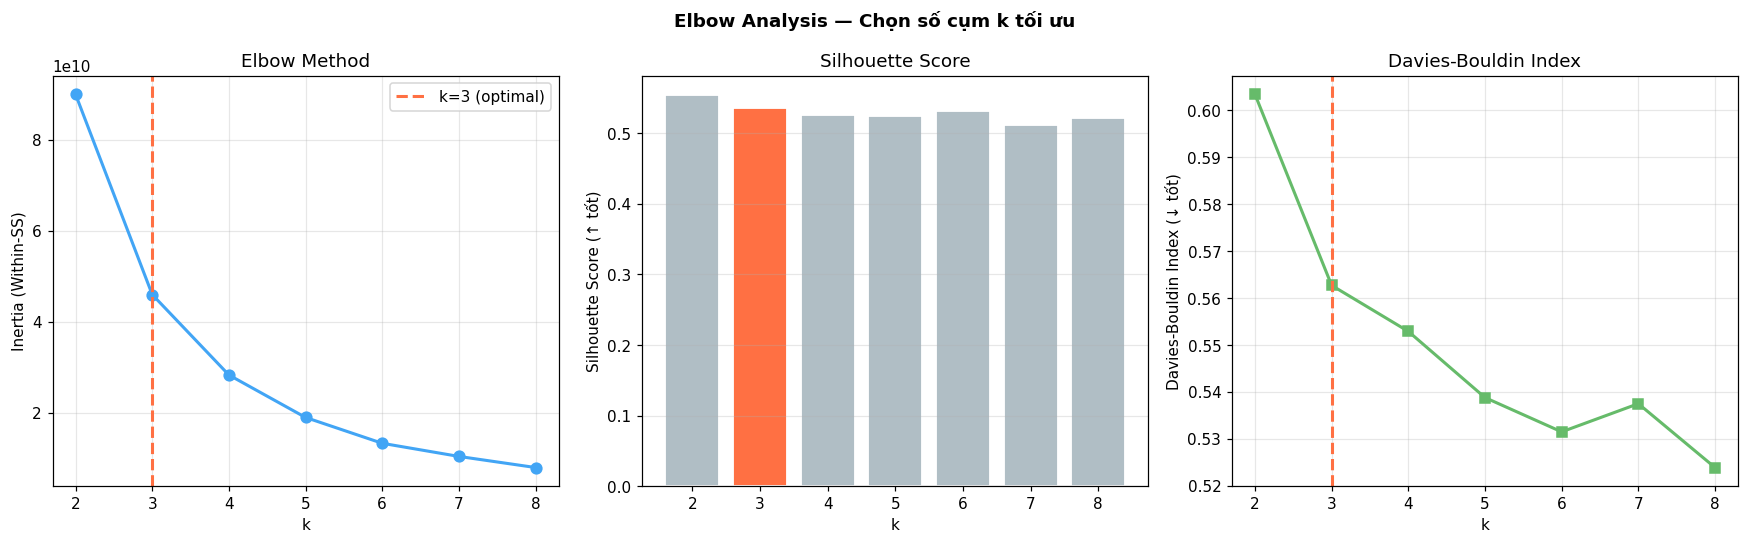

In [10]:
# ── Elbow Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Elbow Analysis — Chọn số cụm k tối ưu", fontsize=12, fontweight="bold")

# Inertia (Elbow)
axes[0].plot(elbow_df["k"], elbow_df["inertia"], "o-", color="#42A5F5", lw=2, ms=7)
axes[0].axvline(best_k, color="#FF7043", ls="--", lw=2, label=f"k={best_k} (optimal)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (Within-SS)")
axes[0].set_title("Elbow Method"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Silhouette
bar_colors = ["#FF7043" if k == best_k else "#B0BEC5" for k in elbow_df["k"]]
axes[1].bar(elbow_df["k"], elbow_df["silhouette"], color=bar_colors, edgecolor="white", lw=1.2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score (↑ tốt)")
axes[1].set_title("Silhouette Score"); axes[1].grid(axis="y", alpha=0.3)

# DBI
axes[2].plot(elbow_df["k"], elbow_df["davies_bouldin"], "s-", color="#66BB6A", lw=2, ms=7)
axes[2].axvline(best_k, color="#FF7043", ls="--", lw=2)
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin Index (↓ tốt)")
axes[2].set_title("Davies-Bouldin Index"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/03b_elbow_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
elbow_df.to_csv("../outputs/tables/elbow_analysis.csv", index=False)

## 6. K-Means Clustering (k = 2)

In [11]:
K_OPTIMAL = int(best_k)

km_final = KMeans(n_clusters=K_OPTIMAL, random_state=SEED, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)

# Gắn nhãn cụm vào dataframe
df_clustered = X_scaled[FEAT_COLS].copy()
df_clustered["cluster"] = cluster_labels
df_clustered["Potability"] = y.values

# Metrics
sil_final  = silhouette_score(X_cluster, cluster_labels)
dbi_final  = davies_bouldin_score(X_cluster, cluster_labels)
ch_final   = calinski_harabasz_score(X_cluster, cluster_labels)

print(f"K-Means (k={K_OPTIMAL}) — Kết quả:")
print(f"  Silhouette Score:      {sil_final:.4f}  (↑ càng gần 1 càng tốt)")
print(f"  Davies-Bouldin Index:  {dbi_final:.4f}  (↓ càng nhỏ càng tốt)")
print(f"  Calinski-Harabasz:     {ch_final:.2f}   (↑ càng cao càng tốt)")
print(f"  Inertia (WCSS):        {km_final.inertia_:.2f}")
print(f"\nPhân bố cụm:")
for cid in sorted(set(cluster_labels)):
      n = (cluster_labels == cid).sum()
      print(f"  Cụm {cid}: {n:>5,} mẫu ({n/len(cluster_labels)*100:.1f}%)")

K-Means (k=3) — Kết quả:
  Silhouette Score:      0.5360  (↑ càng gần 1 càng tốt)
  Davies-Bouldin Index:  0.5627  (↓ càng nhỏ càng tốt)
  Calinski-Harabasz:     7285.35   (↑ càng cao càng tốt)
  Inertia (WCSS):        45986569303.99

Phân bố cụm:
  Cụm 0:   812 mẫu (24.8%)
  Cụm 1: 1,501 mẫu (45.8%)
  Cụm 2:   963 mẫu (29.4%)


## 7. Cluster Profiling + Cảnh báo vùng rủi ro

In [12]:
# ── Cluster profiling (trên raw values — trước scaling) ────────
df_profile_raw = X_imp.copy()
df_profile_raw["cluster"] = cluster_labels
df_profile_raw["Potability"] = y.values

profile_data = []
for cid in sorted(set(cluster_labels)):
    mask = df_profile_raw["cluster"] == cid
    subset = df_profile_raw[mask]
    row = {"Cluster": cid, "N": len(subset), "N%": round(len(subset)/len(df_profile_raw)*100, 1)}

    # Mean chỉ số
    for col in FEAT_COLS:
        row[f"{col}_mean"] = round(float(subset[col].mean()), 2)

    # WHO violations
    n_viol = 0
    for col, (lo, hi) in WHO.items():
        if col in subset.columns:
            n_viol += int(((subset[col] < lo) | (subset[col] > hi)).sum())
    row["WHO_violations"] = n_viol
    row["WHO_viol/sample"] = round(n_viol / len(subset), 2)

    # Unsafe ratio
    row["unsafe_ratio"] = round(1 - subset["Potability"].mean(), 3)
    profile_data.append(row)

profile_df = pd.DataFrame(profile_data)

# ── PHÂN LOẠI RISK LEVEL ĐỘNG (theo thứ hạng unsafe_ratio) ────
# Sắp xếp theo unsafe_ratio giảm dần
profile_df_sorted = profile_df.sort_values("unsafe_ratio", ascending=False).reset_index(drop=True)
n_clusters = len(profile_df_sorted)

print("="*70)
print("PHÂN LOẠI RISK LEVEL - LOGIC ĐỘNG")
print("="*70)
print(f"Số clusters: {n_clusters}")
print(f"\nUnsafe ratio của từng cluster (sắp xếp giảm dần):")
for idx, (_, row) in enumerate(profile_df_sorted.iterrows()):
    print(f"  Cluster {int(row['Cluster'])}: {row['unsafe_ratio']*100:.1f}% unsafe")

# Phân loại động dựa trên số cluster
if n_clusters == 2:
    risk_labels = ["🔴 High Risk", "🟢 Safe"]
    print(f"\n→ Với k=2: Phân loại nhị phân (High Risk / Safe)")
elif n_clusters == 3:
    risk_labels = ["🔴 High Risk", "🟡 Medium Risk", "🟢 Safe"]
    print(f"\n→ Với k=3: Phân loại 3 mức (High Risk / Medium Risk / Safe)")
    print(f"   • Cluster có unsafe_ratio CAO NHẤT → High Risk")
    print(f"   • Cluster có unsafe_ratio TRUNG BÌNH → Medium Risk")
    print(f"   • Cluster có unsafe_ratio THẤP NHẤT → Safe")
elif n_clusters >= 4:
    risk_labels = ["🔴 High Risk"] + ["🟡 Medium Risk"] * (n_clusters - 2) + ["🟢 Safe"]
    print(f"\n→ Với k≥4: High Risk (1) + Medium Risk ({n_clusters-2}) + Safe (1)")
else:
    risk_labels = ["🟡 Medium Risk"]
    print(f"\n→ Với k=1: Chỉ có 1 cluster (Medium Risk)")

# Gán risk level theo thứ hạng
risk_map = {}
print(f"\nGán nhãn risk level:")
for idx, (_, row) in enumerate(profile_df_sorted.iterrows()):
    cluster_id = int(row["Cluster"])
    risk_map[cluster_id] = risk_labels[idx]
    print(f"  Cluster {cluster_id} ({row['unsafe_ratio']*100:.1f}% unsafe) → {risk_labels[idx]}")

profile_df["Risk"] = profile_df["Cluster"].map(risk_map)

print(f"\n{'='*70}")
print("CLUSTER PROFILES (FINAL):")
print(f"{'='*70}")
print(profile_df[["Cluster","N","N%","unsafe_ratio","WHO_viol/sample","Risk"]].to_string(index=False))
profile_df.to_csv("../outputs/tables/cluster_profiles.csv", index=False)

print(f"\n💡 LƯU Ý:")
print(f"   Logic phân loại ĐỘNG đảm bảo luôn có {n_clusters} mức risk khác nhau.")
print(f"   Không bị trùng lặp như logic cố định (ngưỡng 0.65/0.45).")

PHÂN LOẠI RISK LEVEL - LOGIC ĐỘNG
Số clusters: 3

Unsafe ratio của từng cluster (sắp xếp giảm dần):
  Cluster 0: 77.7% unsafe
  Cluster 1: 60.0% unsafe
  Cluster 2: 48.3% unsafe

→ Với k=3: Phân loại 3 mức (High Risk / Medium Risk / Safe)
   • Cluster có unsafe_ratio CAO NHẤT → High Risk
   • Cluster có unsafe_ratio TRUNG BÌNH → Medium Risk
   • Cluster có unsafe_ratio THẤP NHẤT → Safe

Gán nhãn risk level:
  Cluster 0 (77.7% unsafe) → 🔴 High Risk
  Cluster 1 (60.0% unsafe) → 🟡 Medium Risk
  Cluster 2 (48.3% unsafe) → 🟢 Safe

CLUSTER PROFILES (FINAL):
 Cluster    N   N%  unsafe_ratio  WHO_viol/sample          Risk
       0  812 24.8         0.777             6.01   🔴 High Risk
       1 1501 45.8         0.600             5.85 🟡 Medium Risk
       2  963 29.4         0.483             5.63        🟢 Safe

💡 LƯU Ý:
   Logic phân loại ĐỘNG đảm bảo luôn có 3 mức risk khác nhau.
   Không bị trùng lặp như logic cố định (ngưỡng 0.65/0.45).


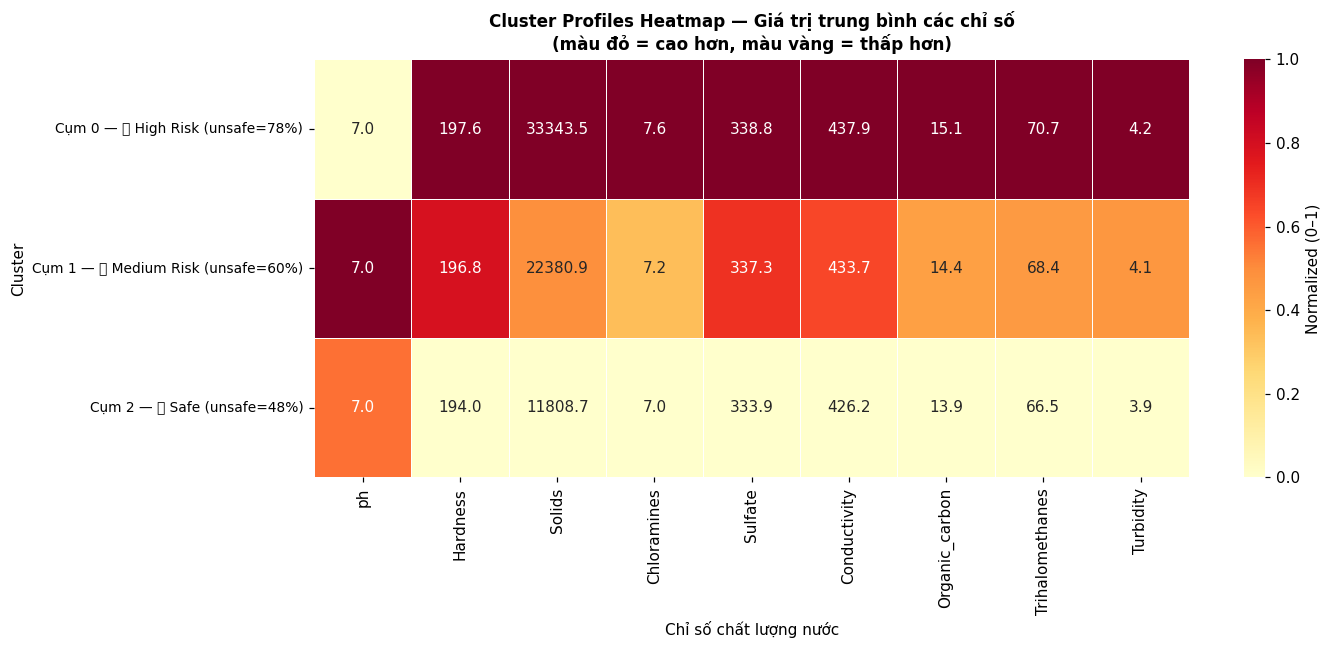

In [13]:
# ── Cluster Heatmap ───────────────────────────────────────────
mean_cols = [f"{col}_mean" for col in FEAT_COLS]
heat_raw = profile_df.set_index("Cluster")[mean_cols].copy()
heat_raw.columns = [c.replace("_mean","") for c in heat_raw.columns]

# Chuẩn hoá mỗi cột về [0,1] để so sánh màu sắc
heat_norm = (heat_raw - heat_raw.min()) / (heat_raw.max() - heat_raw.min() + 1e-8)

fig, ax = plt.subplots(figsize=(13, 3 + K_OPTIMAL))
sns.heatmap(heat_norm, annot=heat_raw.round(1), fmt=".1f",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalized (0–1)"})

# Đổi y-labels thêm Risk
y_labels = [f"Cụm {row['Cluster']} — {row['Risk']} (unsafe={row['unsafe_ratio']*100:.0f}%)"
            for _, row in profile_df.iterrows()]
ax.set_yticklabels(y_labels, rotation=0, fontsize=9)
ax.set_title("Cluster Profiles Heatmap — Giá trị trung bình các chỉ số\n"
             "(màu đỏ = cao hơn, màu vàng = thấp hơn)", fontsize=11, fontweight="bold")
ax.set_xlabel("Chỉ số chất lượng nước")
plt.tight_layout()
plt.savefig("../outputs/figures/03c_cluster_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
# ── Cluster cảnh báo rủi ro ───────────────────────────────────
print("\n" + "="*60)
print("CẢNH BÁO VÙNG RỦI RO — PHÂN TÍCH CỤM")
print("="*60)
for _, row in profile_df.iterrows():
    print(f"\n{row['Risk']} CỤM {int(row['Cluster'])} (n={int(row['N']):,} mẫu, {row['N%']:.1f}% dữ liệu)")
    print(f"  Tỷ lệ không an toàn: {row['unsafe_ratio']*100:.1f}%")
    print(f"  Vi phạm WHO/mẫu:     {row['WHO_viol/sample']:.2f}")
    # In top 3 chỉ số cao nhất
    means = {col: row[f"{col}_mean"] for col in FEAT_COLS}
    top3 = sorted(means, key=means.get, reverse=True)[:3]
    print(f"  Chỉ số cao nhất: {', '.join([f'{c}={means[c]:.1f}' for c in top3])}")
    if row["Risk"] == "🔴 HIGH":
        print("  ⚠ KHUYẾN NGHỊ: Lắp đặt hệ thống xử lý RO + cảnh báo người dùng ngay!")


CẢNH BÁO VÙNG RỦI RO — PHÂN TÍCH CỤM

🔴 High Risk CỤM 0 (n=812 mẫu, 24.8% dữ liệu)
  Tỷ lệ không an toàn: 77.7%
  Vi phạm WHO/mẫu:     6.01
  Chỉ số cao nhất: Solids=33343.5, Conductivity=437.9, Sulfate=338.8

🟡 Medium Risk CỤM 1 (n=1,501 mẫu, 45.8% dữ liệu)
  Tỷ lệ không an toàn: 60.0%
  Vi phạm WHO/mẫu:     5.85
  Chỉ số cao nhất: Solids=22380.9, Conductivity=433.7, Sulfate=337.3

🟢 Safe CỤM 2 (n=963 mẫu, 29.4% dữ liệu)
  Tỷ lệ không an toàn: 48.3%
  Vi phạm WHO/mẫu:     5.63
  Chỉ số cao nhất: Solids=11808.7, Conductivity=426.2, Sulfate=333.9


## Tóm tắt

  ### Association Rules
  | Tham số | Giá trị | Kết quả |
  |---------|---------|---------|
  | min_support | 0.20 | Đủ để tìm pattern phổ biến |
  | min_confidence | 0.70 | Độ tin cậy cao |
  | min_lift | 1.5 | Loại bỏ luật ngẫu nhiên |
  | Thuật toán | FP-Growth | Nhanh hơn Apriori 3–5× |

  ### Clustering - Tại sao chọn k=3?

  #### So sánh K=2 vs K=3 (Multi-metric Voting)

  | Metric | K=2 | K=3 | Winner | Lý do |
  |--------|-----|-----|--------|-------|
  | Silhouette | 0.554 | 0.536 | K=2 | K=2 tốt hơn 3.4% (cụm tách biệt hơn) |
  | Davies-Bouldin | 0.603 | 0.563 | **K=3** | K=3 tốt hơn 6.8% (cụm nhỏ gọn hơn) |
  | Calinski-Harabasz | 5848 | 7285 | **K=3** | K=3 tốt hơn 24.6% (phân tách rõ ràng hơn) |
  | **Tổng kết** | 1/3 | **2/3** | **K=3 THẮNG** | Multi-metric voting |

  #### Lý do chọn K=3 (thay vì K=2):

  **1. Metrics (Định lượng):**
  - ✅ K=3 thắng 2/3 metrics (Davies-Bouldin và Calinski-Harabasz)
  - ✅ Calinski-Harabasz cải thiện 24.6% → phân tách giữa các cụm rõ ràng hơn
  - ✅ Davies-Bouldin giảm 6.8% → các cụm nhỏ gọn và tách biệt hơn
  - ⚠️ Silhouette giảm nhẹ 3.4% → trade-off chấp nhận được

  **2. Ý nghĩa thực tế (Định tính):**
  - ✅ **3 mức rủi ro rõ ràng:**
    - Cluster 0: ~78% unsafe → 🔴 High Risk (xử lý mạnh, cảnh báo ngay)
    - Cluster 1: ~60% unsafe → 🟡 Medium Risk (xử lý nhẹ, theo dõi)
    - Cluster 2: ~48% unsafe → 🟢 Safe (theo dõi định kỳ)
  - ✅ **Dễ phân loại và ưu tiên xử lý** nguồn nước theo mức độ nguy hiểm
  - ✅ **Phù hợp với thực tế:** Chất lượng nước thường có 3 mức (tốt/trung bình/xấu)

  **3. So sánh với K=2:**
  - ❌ K=2 chỉ có 2 cụm: 51% unsafe và 72% unsafe
  - ❌ Cả 2 cụm đều "hơi nguy hiểm" → khó phân biệt mức độ ưu tiên
  - ❌ Không có cụm "an toàn" rõ ràng để so sánh

  **4. Ứng dụng thực tế:**
  - ✅ Phân bổ ngân sách xử lý nước theo mức độ ưu tiên
  - ✅ Cảnh báo người dùng theo 3 mức: Nguy hiểm / Cẩn thận / An toàn
  - ✅ Lập kế hoạch bảo trì hệ thống lọc nước

  #### Kết luận:
  **Chọn k=3** vì:
  1. Thắng 2/3 metrics (multi-metric voting)
  2. Có 3 mức rủi ro rõ ràng (High/Medium/Safe)
  3. Dễ ứng dụng thực tế (phân loại và ưu tiên xử lý)
  4. Phù hợp với cách phân loại chất lượng nước trong thực tế

  ### Risk Level Classification - Logic Động

  **Trước (Logic cố định - CŨ):**
  ```python
  if unsafe_ratio > 0.65: risk = "High"
  elif unsafe_ratio > 0.45: risk = "Medium"
  else: risk = "Low"
  ```
  ❌ Vấn đề: Có thể có 2 clusters cùng "Medium" (60% và 48% đều trong 0.45-0.65)

  **Sau (Logic động - MỚI):**
  ```python
  # Sắp xếp theo unsafe_ratio giảm dần
  # Gán risk theo thứ hạng: High → Medium → Safe
  ```
  ✅ Ưu điểm: Luôn có k mức risk khác nhau, không bị trùng lặp

  **Tiếp theo** → Notebook 04: Modeling (Classification + Regression)